### Hydrostats walkthrough

#### Import and path

In [30]:
import numpy as np
import geopandas as gpd
import pandas as pd
import rasterio
import os
from pathlib import Path
from rasterio.windows import from_bounds
from shapely.geometry import Point, LineString
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from geopy.geocoders import Nominatim

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'

##### convert to parquet (optional)

accelerates working greatly as tif files can be slow. These are all files relevant for Germany

In [31]:
def export_classes_to_parquet(file_mapping, lat_range=(47, 55), lon_range=(5, 15), output_dir="water_data"):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for file_path, label in file_mapping.items():
        if not os.path.exists(file_path):
            print(f"Datei nicht gefunden: {file_path}")
            continue

        with rasterio.open(file_path) as src:
            window = from_bounds(lon_range[0], lat_range[0], lon_range[1], lat_range[1], src.transform)
            data = src.read(1, window=window)
            win_transform = src.window_transform(window)

            mask = (data > 0) & (data <= 100)
            rows, cols = np.where(mask)
            values = data[mask]
            lon, lat = rasterio.transform.xy(win_transform, rows, cols) #type: ignore

            df = pd.DataFrame({
                'percentage': values,
                'longitude': lon,
                'latitude': lat,
                'class_label': label
            })

            geometry = [Point(xy) for xy in zip(df.longitude, df.latitude)]
            gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")
            gdf = gdf.to_crs(epsg=25832)

            file_id = Path(file_path).name.split('_')[-2]
            output_name = f"class_{file_id}_{label.lower()}.parquet"
            output_path = os.path.join(output_dir, output_name)

            gdf.to_parquet(output_path)

class_files = {
    DATA_DIR / "GLWD_v2_0_class_01_pct.tif": 'Freshwater_Lake',
    DATA_DIR / "GLWD_v2_0_class_03_pct.tif": 'Reservoir',
    DATA_DIR / "GLWD_v2_0_class_04_pct.tif": 'Large_River',
    DATA_DIR / "GLWD_v2_0_class_05_pct.tif": 'Estuarine_River',
    DATA_DIR / "GLWD_v2_0_class_06_pct.tif": 'Other_Permanent_Waterbody',
    DATA_DIR / "GLWD_v2_0_class_07_pct.tif": 'Small_Stream',
    DATA_DIR / "GLWD_v2_0_class_29_pct.tif": 'Saltmarsh',
    DATA_DIR / "GLWD_v2_0_class_31_pct.tif": 'Coastal_Wetland'
}

export_classes_to_parquet(class_files)

In [20]:
lake_df = gpd.read_parquet("water_data/class_01_freshwater_lake.parquet")
reservoir_df = gpd.read_parquet("water_data/class_03_reservoir.parquet")
river_df = gpd.read_parquet("water_data/class_04_large_river.parquet")
estuarine_river_df = gpd.read_parquet("water_data/class_05_estuarine_river.parquet")
other_water_df = gpd.read_parquet("water_data/class_06_other_permanent_waterbody.parquet")
small_stream_df = gpd.read_parquet("water_data/class_07_small_stream.parquet")
saltmarsh_df = gpd.read_parquet("water_data/class_29_saltmarsh.parquet")
coastal_wetland_df = gpd.read_parquet("water_data/class_31_coastal_wetland.parquet")

all_lakes_df = pd.concat([lake_df, reservoir_df, other_water_df], ignore_index=True)
all_rivers_df = pd.concat([river_df, estuarine_river_df, small_stream_df], ignore_index=True)
sea_related_df = pd.concat([saltmarsh_df, coastal_wetland_df], ignore_index=True)

print("Loaded and combined water body dataframes.")

Loaded and combined water body dataframes.


#### Analysis frame work

The primary function handles the dynamic spatial query. It converts the target coordinate into a local metric projection, establishes the analysis radius, and intersects the buffer zone with global coastline and surface water datasets.

In [32]:
def analyze_water_data(longitude, latitude, radius_m):
    glwd_pixel_area_sq_m = 1e6

    input_point_gdf = gpd.GeoDataFrame(
        geometry=[Point(longitude, latitude)],
        crs="EPSG:4326"
    )

    target_crs = "EPSG:25832"
    input_point_gdf_proj = input_point_gdf.to_crs(target_crs)
    point_proj = input_point_gdf_proj.geometry.iloc[0]

    buffer_geometry = point_proj.buffer(radius_m) #type: ignore
    buffer_gdf = gpd.GeoDataFrame(
        geometry=[buffer_geometry],
        crs=target_crs
    )

    all_lakes_proj = all_lakes_df.to_crs(target_crs) #type: ignore
    all_rivers_proj = all_rivers_df.to_crs(target_crs) #type: ignore
    sea_related_proj = sea_related_df.to_crs(target_crs) #type: ignore

    all_freshwater_bodies_proj = pd.concat([all_rivers_proj, all_lakes_proj], ignore_index=True)

    nearest_freshwater_point = None
    if not all_freshwater_bodies_proj.empty:
        distances_to_freshwater = all_freshwater_bodies_proj.distance(point_proj)
        nearest_freshwater_distance = distances_to_freshwater.min()
        nearest_freshwater_idx = distances_to_freshwater.idxmin()
        nearest_freshwater_point = all_freshwater_bodies_proj.loc[nearest_freshwater_idx].geometry
    else:
        nearest_freshwater_distance = np.inf

    nearest_coastal_point = None
    if not sea_related_proj.empty:
        distances_to_sea = sea_related_proj.distance(point_proj)
        nearest_sea_distance = distances_to_sea.min()
        nearest_sea_idx = distances_to_sea.idxmin()
        nearest_coastal_point = sea_related_proj.loc[nearest_sea_idx].geometry
    else:
        nearest_sea_distance = np.inf

    rivers_in_buffer = gpd.overlay(all_rivers_proj, buffer_gdf, how='intersection')
    sea_in_buffer = gpd.overlay(sea_related_proj, buffer_gdf, how='intersection')
    lakes_in_buffer = gpd.overlay(all_lakes_proj, buffer_gdf, how='intersection')


    river_area_in_buffer = (rivers_in_buffer['percentage'] / 100 * glwd_pixel_area_sq_m).sum()
    sea_area_in_buffer = (sea_in_buffer['percentage'] / 100 * glwd_pixel_area_sq_m).sum()
    lake_area_in_buffer = (lakes_in_buffer['percentage'] / 100 * glwd_pixel_area_sq_m).sum()

    total_water_area_in_buffer = river_area_in_buffer + sea_area_in_buffer + lake_area_in_buffer

    _, ax = plt.subplots(1, 1, figsize=(12, 12))

    buffer_gdf.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.5)
    input_point_gdf_proj.plot(ax=ax, color='red', marker='X', markersize=100, zorder=5)

    ax.set_title(f'Data Analysis for Point ({longitude:.3f} E, {latitude:.3f} N) with {radius_m/1000:.1f} km Radius')
    ax.set_axis_off()

    legend_elements = [
        Patch(facecolor='lightgrey', edgecolor='black', alpha=0.5, label=f'Buffer ({radius_m/1000:.1f} km)'),
        Line2D([0], [0], marker='X', color='w', label='You', markerfacecolor='red', markersize=10)
    ]

    if not rivers_in_buffer.empty:
        rivers_in_buffer.plot(ax=ax, color='blue', alpha=0.7)
        legend_elements.append(Patch(facecolor='blue', alpha=0.7, label='Rivers in Buffer'))
    if not lakes_in_buffer.empty:
        lakes_in_buffer.plot(ax=ax, color='cyan', alpha=0.7)
        legend_elements.append(Patch(facecolor='cyan', alpha=0.7, label='Lakes and Standing Water in Buffer'))
    if not sea_in_buffer.empty:
        sea_in_buffer.plot(ax=ax, color='green', alpha=0.7)
        legend_elements.append(Patch(facecolor='green', alpha=0.7, label='Coastal and Saltwater Areas in Buffer'))

    if nearest_freshwater_distance != np.inf and nearest_freshwater_distance <= radius_m:
        line_to_freshwater = LineString([point_proj, nearest_freshwater_point])
        gpd.GeoSeries([line_to_freshwater], crs=target_crs).plot(ax=ax, color='blue', linestyle='--', linewidth=2, zorder=4)
        legend_elements.append(Line2D([0], [0], color='blue', linestyle='--', linewidth=2, label=f'Direct Line to Nearest Freshwater Body ({nearest_freshwater_distance/1000:.2f} km)'))
    elif nearest_freshwater_distance != np.inf and nearest_freshwater_distance > radius_m:
        ax.annotate(f"Nearest freshwater body ({nearest_freshwater_distance/1000:.2f} km) is outside the buffer",
                    xy=(0.02, 0.95), xycoords='axes fraction', fontsize=12, color='blue', ha='left', va='top')

    if nearest_sea_distance != np.inf and nearest_sea_distance <= radius_m:
        line_to_sea = LineString([point_proj, nearest_coastal_point])
        gpd.GeoSeries([line_to_sea], crs=target_crs).plot(ax=ax, color='green', linestyle='--', linewidth=2, zorder=4)
        legend_elements.append(Line2D([0], [0], color='green', linestyle='--', linewidth=2, label=f'Direct Line to Nearest Coastal Feature ({nearest_sea_distance/1000:.2f} km)'))
    elif nearest_sea_distance != np.inf and nearest_sea_distance > radius_m:
        ax.annotate(f"Nearest coastal feature ({nearest_sea_distance/1000:.2f} km) is outside the buffer",
                    xy=(0.02, 0.90), xycoords='axes fraction', fontsize=12, color='green', ha='left', va='top')

    ax.legend(handles=legend_elements)
    ax.set_aspect('equal', adjustable='box')
    plt.grid(True)
    plt.show()

    results = {
        "Distance to nearest freshwater body (km)": nearest_freshwater_distance / 1000 if nearest_freshwater_distance != np.inf else np.inf,
        "Distance to nearest coastal feature (km)": nearest_sea_distance / 1000 if nearest_sea_distance != np.inf else np.inf,
        "Total water area in buffer (km²)": total_water_area_in_buffer / 1000000 if total_water_area_in_buffer != np.inf else np.inf,
    }
    
    return results

Some places to play with:
- Best example Lake Constance: 47.35, 9.28 (with radius 50 km)
- Berlin: (52.520008, 13.404954)
- Kiel: (54.329427984985294, 10.133712799577005),
- Munich: (48.135125, 11.581980),
- Cologne: (50.935173, 6.953101),
- Frankfurt: (50.110922, 8.6821),

#### Input with coordinates

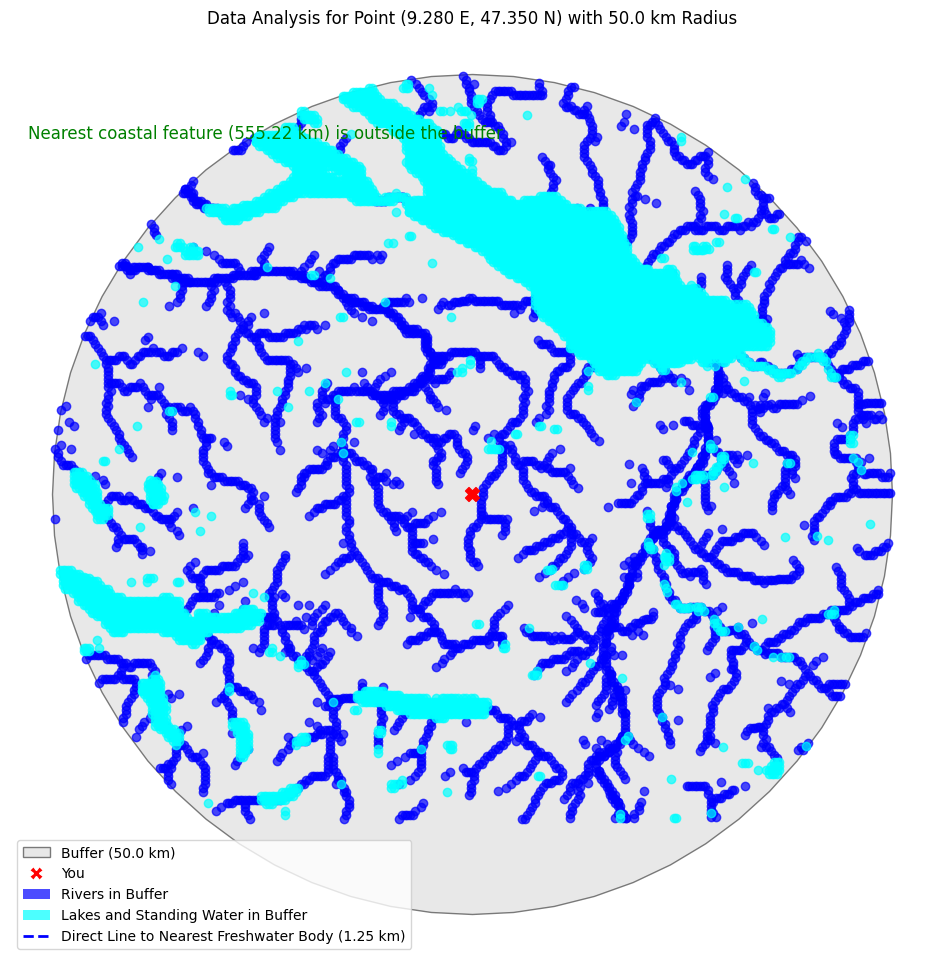

Analyseergebnisse:
- Distance to nearest freshwater body (km): 1.25
- Distance to nearest coastal feature (km): 555.22
- Total water area in buffer (km²): 4536.72


In [35]:
latitude_point, longitude_point = 47.35, 9.28
radius_test_in_m = 50000

water_analysis_results = analyze_water_data(longitude_point, latitude_point, radius_test_in_m)

print("Analyseergebnisse:")
for key, value in water_analysis_results.items(): #type: ignore
    display_key = key.replace('_', ' ')
    print(f"- {display_key}: {value:.2f}")

#### Input with name

52.5332165 13.3597957


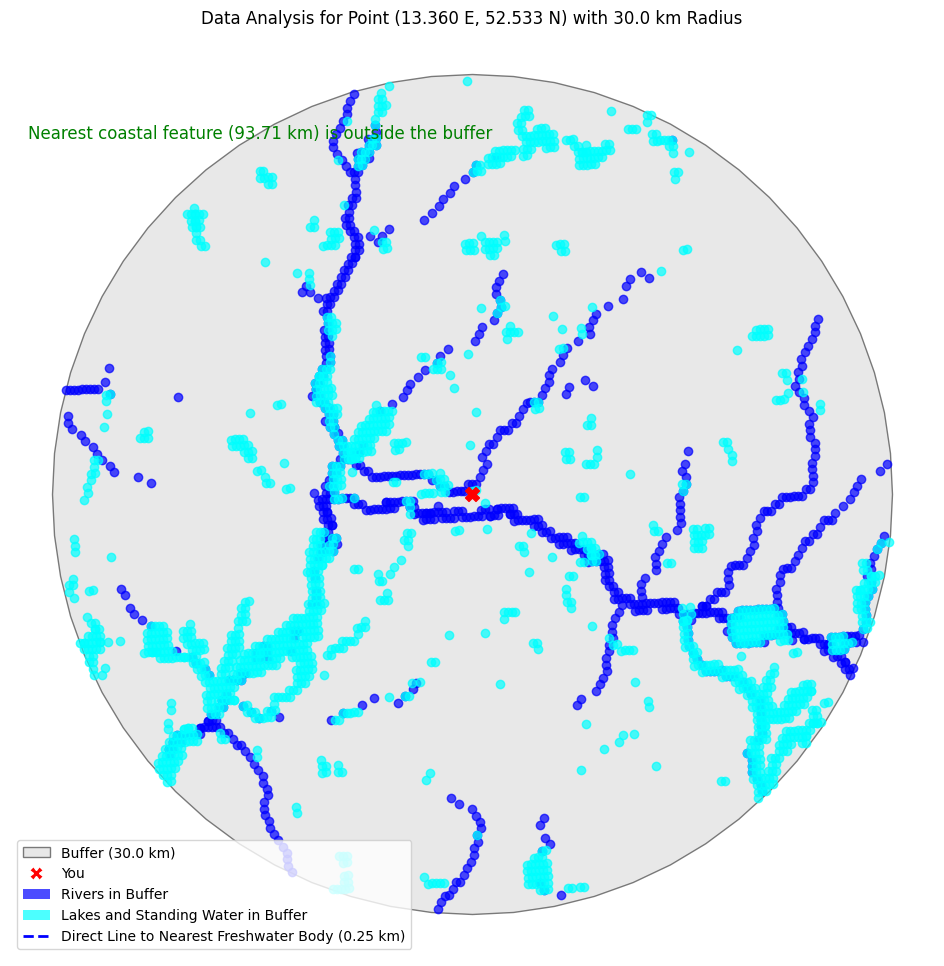

Analysis Results:
- Distance to nearest freshwater body (km): 0.25
- Distance to nearest coastal feature (km): 93.71
- Total water area in buffer (km²): 603.87


In [36]:
location = Nominatim(user_agent="GetLoc")

place = input("Enter a location in Germany to perform the analysis: ")
buffer_radius = float(input("Enter the buffer radius in kilometers: ")) * 1000
getLocation = location.geocode(place)
location_latitude = getLocation.latitude # type: ignore
location_longitude = getLocation.longitude # type: ignore
print(location_latitude, location_longitude)
water_analysis_results = analyze_water_data(location_longitude, location_latitude, buffer_radius)
print("Analysis Results:")
for key, value in water_analysis_results.items(): #type: ignore
    display_key = key.replace('_', ' ')
    print(f"- {display_key}: {value:.2f}")